In [2]:
import sys
import os

# Add the project root (where the nn/ folder lives) to the import path
sys.path.insert(0, os.path.abspath('..'))

# Now you can import from nn
from nn import network2
from nn import mnist_loader

Epoch 0 training complete
Cost on training data: 0.3297166361363805
Epoch 0 training complete
Cost on training data: 0.1371454004201167
Epoch 0 training complete
Cost on training data: 0.3250714335575769
Epoch 0 training complete
Cost on training data: 0.13229996611220152
Epoch 0 training complete
Cost on training data: 0.3202771250498675
Epoch 0 training complete
Cost on training data: 0.12776730703953249
Epoch 0 training complete
Cost on training data: 0.31533308998883125
Epoch 0 training complete
Cost on training data: 0.12351920562744467
Epoch 0 training complete
Cost on training data: 0.3102394586631111
Epoch 0 training complete
Cost on training data: 0.11953063779760495
Epoch 0 training complete
Cost on training data: 0.30499720648382234
Epoch 0 training complete
Cost on training data: 0.11577934550091999
Epoch 0 training complete
Cost on training data: 0.29960824804679126
Epoch 0 training complete
Cost on training data: 0.11224547444558328
Epoch 0 training complete
Cost on train

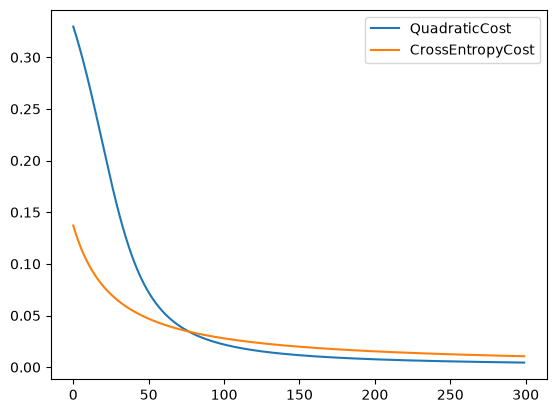

In [3]:
# PART 1 - recreate the cost graphs

import numpy as np

net1 = network2.Network([1, 1], cost=network2.QuadraticCost)
net2 = network2.Network([1, 1], cost=network2.CrossEntropyCost)

training_data = [(np.array([[1.0]]), np.array([[0.0]]))]
net1.weights= [np.array([[0.6]])]
net1.biases = [np.array([[0.9]])]

costs1 = []
costs2 = []
for _ in range(300):
    (_, _, train_cost, _) = net1.SGD(training_data, 1, 1, 0.15, 0.0, monitor_training_cost=True)
    costs1.append(train_cost[0])
    (_, _, train_cost, _) = net2.SGD(training_data, 1, 1, 0.15, 0.0, monitor_training_cost=True)
    costs2.append(train_cost[0])

import matplotlib.pyplot as plt

plt.plot(costs1, label='QuadraticCost')
plt.plot(costs2, label='CrossEntropyCost')
plt.legend()
plt.show()



Epoch 0 training complete
Cost on training data: 1.8027675347579015
Accuracy on training data: 658 / 1000
Cost on evaluation data: 2.0726947890592453
Accuracy on evaluation data: 5782 / 10000
Epoch 1 training complete
Cost on training data: 1.2689924617039843
Accuracy on training data: 796 / 1000
Cost on evaluation data: 1.6615522889536334
Accuracy on evaluation data: 6976 / 10000
Epoch 2 training complete
Cost on training data: 1.0488132757362212
Accuracy on training data: 842 / 1000
Cost on evaluation data: 1.50084938291962
Accuracy on evaluation data: 7277 / 10000
Epoch 3 training complete
Cost on training data: 0.8717317351328573
Accuracy on training data: 883 / 1000
Cost on evaluation data: 1.3671761381791874
Accuracy on evaluation data: 7600 / 10000
Epoch 4 training complete
Cost on training data: 0.7885554089333475
Accuracy on training data: 894 / 1000
Cost on evaluation data: 1.3185645811173579
Accuracy on evaluation data: 7723 / 10000
Epoch 5 training complete
Cost on training

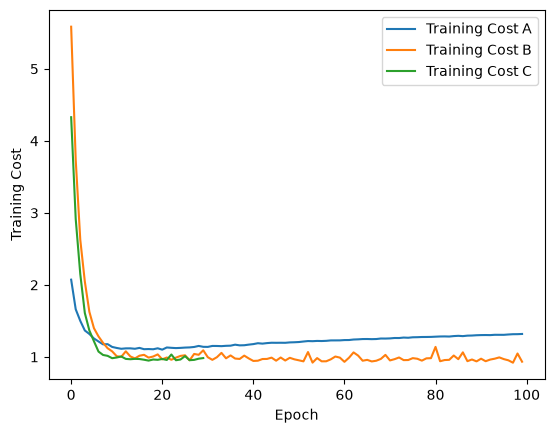

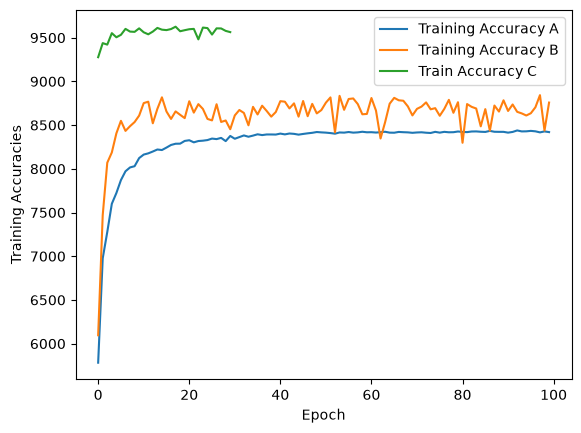

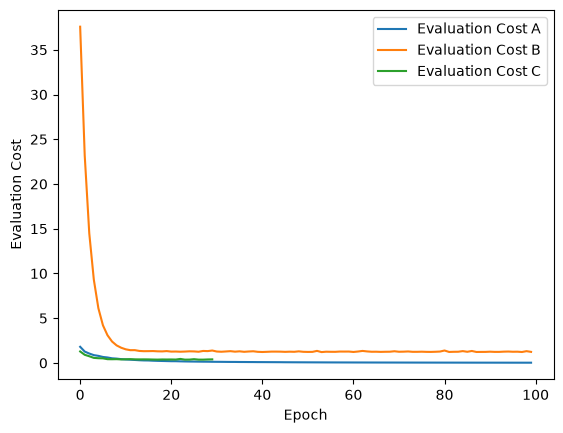

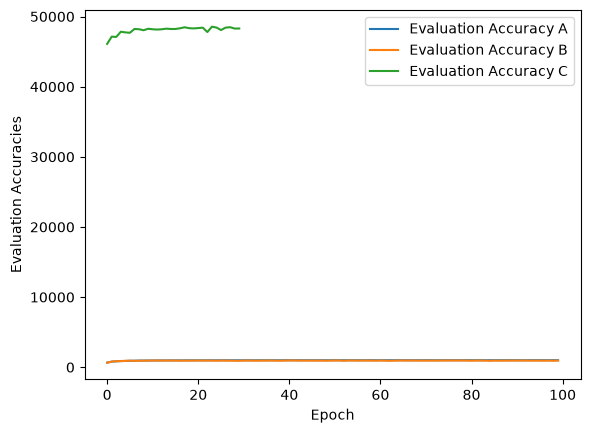

In [5]:
# PART 2 - Overfitting and regularization
netA = network2.Network(
    [784, 30, 10],
    cost=network2.CrossEntropyCost
)

netB = network2.Network(
    [784, 30, 10],
    cost=network2.CrossEntropyCost
)

netC = network2.Network(
    [784, 30, 10],
    cost=network2.CrossEntropyCost
)

netA.large_weight_initializer()
netB.large_weight_initializer()
netC.large_weight_initializer()


training_data, validation_data, test_data = mnist_loader.load_data_wrapper('../nn/mnist.pkl.gz')
training_data = list(training_data)
validation_data = list(validation_data)
test_data = list(test_data)

tcostA, taccA, ecostA, eaccA = netA.SGD(
    training_data[:1000],
    epochs=100,
    mini_batch_size=10,
    eta=0.5,
    evaluation_data=validation_data,
    lmbda=0,
    monitor_training_cost=True,
    monitor_training_accuracy=True,
    monitor_evaluation_cost=True,
    monitor_evaluation_accuracy=True
)

tcostB, taccB, ecostB, eaccB = netB.SGD(
    training_data[:1000],
    epochs=100,
    mini_batch_size=10,
    eta=0.5,
    evaluation_data=validation_data,
    lmbda=5,
    monitor_training_cost=True,
    monitor_training_accuracy=True,
    monitor_evaluation_cost=True,
    monitor_evaluation_accuracy=True
)

tcostC, taccC, ecostC, eaccC = netC.SGD(
    training_data[:50000],
    epochs=30,
    mini_batch_size=10,
    eta=0.5,
    evaluation_data=validation_data,
    lmbda=5,
    monitor_training_cost=True,
    monitor_training_accuracy=True,
    monitor_evaluation_cost=True,
    monitor_evaluation_accuracy=True
)

plt.plot(tcostA, label='Training Cost A')
plt.plot(tcostB, label='Training Cost B')
plt.plot(tcostC, label='Training Cost C')
plt.xlabel('Epoch')
plt.ylabel('Training Cost')
plt.legend()
plt.show()

plt.plot(taccA, label='Training Accuracy A')
plt.plot(taccB, label='Training Accuracy B')
plt.plot(taccC, label='Train Accuracy C')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracies')
plt.legend()
plt.show()

plt.plot(ecostA, label='Evaluation Cost A')
plt.plot(ecostB, label='Evaluation Cost B')
plt.plot(ecostC, label='Evaluation Cost C')
plt.xlabel('Epoch')
plt.ylabel('Evaluation Cost')
plt.legend()
plt.show()

plt.plot(eaccA, label='Evaluation Accuracy A')
plt.plot(eaccB, label='Evaluation Accuracy B')
plt.plot(eaccC, label='Evaluation Accuracy C')
plt.xlabel('Epoch')
plt.ylabel('Evaluation Accuracies')
plt.legend()
plt.show()